In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [1]:
%cd ..
!pwd

/vol/data/foundation_model_multiplexed_imaging/models/virtue
/vol/data/foundation_model_multiplexed_imaging/models/virtue


In [2]:
#Extract Embddings from .pt file 

import torch
import os

# Pfade anpassen auf marker_embeddings
base_path = "/vol/data/foundation_model_multiplexed_imaging/models/virtue"
input_dir = os.path.join(base_path, "assets/old_marker_embeddings")
output_dir = os.path.join(base_path, "assets/cleaned_embeddings")

os.makedirs(output_dir, exist_ok=True)

print(f"Lade Dateien aus: {input_dir}")
files = [f for f in os.listdir(input_dir) if f.endswith(".pt")]
print(f"Gefundene .pt Dateien: {len(files)}\n")

for file in sorted(files):
    path = os.path.join(input_dir, file)
    data = torch.load(path, map_location='cpu')
    
    # Extraktion aus der ESM-Struktur
    if isinstance(data, dict) and 'mean_representations' in data:
        # Den Layer-Index automatisch bestimmen (z.B. 33)
        layer = list(data['mean_representations'].keys())[0]
        tensor = data['mean_representations'][layer]
        
        # Speichern des reinen Tensors
        torch.save(tensor, os.path.join(output_dir, file))
        
        # Details printen
        print(f"✅ {file}")
        print(f"   Shape: {list(tensor.shape)}")
        print(f"   Mean:  {tensor.mean().item():.4f}")
    else:
        print(f"⚠️  {file} übersprungen (keine 'mean_representations' gefunden)")

print(f"\nFertig! Die bereinigten Tensoren liegen in: {output_dir}")

Lade Dateien aus: /vol/data/foundation_model_multiplexed_imaging/models/virtue/assets/old_marker_embeddings
Gefundene .pt Dateien: 3

✅ P60709.pt
   Shape: [640]
   Mean:  0.0036
✅ P68431.pt
   Shape: [640]
   Mean:  0.0035
✅ P68871.pt
   Shape: [640]
   Mean:  0.0034

Fertig! Die bereinigten Tensoren liegen in: /vol/data/foundation_model_multiplexed_imaging/models/virtue/assets/cleaned_embeddings


In [4]:
import os
from omegaconf import OmegaConf
import torch
from modules.multiplex_virtues import MultiplexVirtues
from utils.utils import load_marker_embeddings, load_marker_embedding_dict
from safetensors.torch import load_file

# path definition 
PATH_BASE_CONFIG = "configs/base_config.yaml"
PATH_MARKER_EMBEDDINGS = "assets/cleaned_embeddings/"
weights_dir = "assets/checkpoints" 
weights_filename = "model.safetensors"
weights_full_path = os.path.join(weights_dir, weights_filename)

# gather variables needed for model 
config = OmegaConf.load(PATH_BASE_CONFIG)
print("Config is loaded succesfully, yuhu")

#bias_embeddings = load_marker_embeddings(PATH_MARKER_EMBEDDINGS)
#bias_embeddings_dict = load_marker_embedding_dict(PATH_MARKER_EMBEDDINGS) # Klammern ergänzt
#print("\n--- 🔍 Sanity Check: Embeddings ---")#
#print(f"Gesamt-Tensor Shape: {bias_embeddings.shape}")

model = MultiplexVirtues(
    use_default_config=False,
    prior_bias_embeddings=None,       # WICHTIG: Auf None setzen
    prior_bias_embedding_type='empty', # WICHTIG: Modus auf 'empty' ändern
    patch_size=config.model.patch_size,
    model_dim=config.model.model_dim,
    feedforward_dim=config.model.feedforward_dim,
    encoder_pattern=config.model.encoder_pattern,
    num_encoder_heads=config.model.num_encoder_heads,
    decoder_pattern=config.model.decoder_pattern,
    num_decoder_heads=config.model.num_decoder_heads,
    num_hidden_layers=config.model.num_decoder_hidden_layers,
    positional_embedding_type=config.model.positional_embedding_type,
    dropout=0.0,
    group_layers=config.model.group_layers,
    norm_after_encoder_decoder=config.model.norm_after_encoder_decoder,
    verbose=True
)

# --- 2. Loading the Weights ---
print(f"Loading weights from: {weights_full_path}")

# Load the weights from the safetensors file
state_dict = load_file(weights_full_path)
model.load_state_dict(state_dict, strict=False)

# --- 3. Final Preparation ---
# Set the model to evaluation mode (disables dropout)
model.eval()

# Move the model to GPU if available for faster inference
if torch.cuda.is_available():
    model.cuda()
    print("✅ Model instantiated and moved to GPU.")
else:
    print("✅ Model instantiated on CPU.")

Config is loaded succesfully, yuhu
Using addition for prior_embedding fusion
Loading weights from: assets/checkpoints/model.safetensors
✅ Model instantiated and moved to GPU.


In [5]:
import gc
import torch

# Lösche alte Variablen, falls sie noch existieren
if 'output' in locals(): del output
if 'images_list' in locals(): del images_list

# Erzwinge die Müllabfuhr
gc.collect()
# Leere den PyTorch Cache
torch.cuda.empty_cache()

print(f"Freier Speicher auf GPU: {torch.cuda.mem_get_info()[0] / 1024**3:.2f} GB")

Freier Speicher auf GPU: 10.21 GB


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
import gc
from einops import rearrange

class BloodMNISTInference(Dataset):
    # embedding_dict Argument entfernen, da wir es nicht mehr haben
    def __init__(self, npz_path, channel_names): 
        data = np.load(npz_path)
        self.images = data['train_images']
        self.labels = data['train_labels']
        
        # WICHTIG: Dummy Channel IDs erstellen.
        # Der Wert ist egal (da kein Lookup passiert), aber die Länge muss stimmen.
        # Wir nehmen einfach 0, 1, 2, ...
        num_channels = len(channel_names)
        self.channel_ids = torch.arange(num_channels)

    def __len__(self):
        return len(self.images)

 
    def __getitem__(self, idx):
        img = self.images[idx].astype("float32") / 255.0
        img_tensor = torch.from_numpy(img)
        
        # Einfache Standardisierung für BloodMNIST (Globaler Schnitt/Std über den Datensatz)
        # Diese Werte sind Beispiele; idealerweise berechnest du sie einmal für BloodMNIST
        mean = img_tensor.mean()
        std = img_tensor.std()
        img_tensor = (img_tensor - mean) / (std + 1e-6) # +1e-6 verhindert Division durch 0
        
        img_tensor = rearrange(img_tensor, 'h w c -> c h w')
        return img_tensor, self.labels[idx], self.channel_ids

# --- 2. Create a RANDOM Subset of 1000 images ---

PATH_BLOODMNIST = "datasets/bloodmnist_128/bloodmnist_128.npz"

# HIER IST DIE KORREKTUR:
# Wir definieren channel_names. Da BloodMNIST RGB ist, brauchen wir 3 Einträge.
# Die Namen selbst sind im 'empty'-Modus egal, nur die Anzahl (3) zählt.
channel_names = ["Red", "Green", "Blue"] 

# Jetzt ist channel_names definiert und kann übergeben werden:
full_dataset = BloodMNISTInference(PATH_BLOODMNIST, channel_names)

# Generate 1000 random indices from the whole dataset
np.random.seed(42) # For reproducibility
random_indices = np.random.choice(len(full_dataset), 1000, replace=False)
inference_subset = Subset(full_dataset, random_indices)

# shuffle=True is now optional because the subset is already random
inference_loader = DataLoader(inference_subset, batch_size=2, shuffle=True)

# --- 3. Fixed Embedding & Label Extraction ---
all_embeddings = []
all_labels = []

model.eval()
print("Starting extraction of RANDOM samples...")

with torch.no_grad():
    for i, (batch_images, batch_labels, batch_ch_ids) in enumerate(inference_loader):
        if i * 2 >= 1000: break
            
        images_list = [img.cuda().float() for img in batch_images]
        ids_list = [ids.cuda() for ids in batch_ch_ids]
        
        output = model(images_list, ids_list)
        
        # Extract embeddings
        embeddings_list = output.channel_token_embeddings 
        batch_emb = torch.stack(embeddings_list).detach().cpu()
        all_embeddings.append(batch_emb.mean(dim=1))
        
        # IMPORTANT: Get labels directly from the DataLoader (shuffled correctly!)
        all_labels.append(batch_labels.detach().cpu())

        if i % 100 == 0:
            print(f"Processed: {i*2}/1000 images...")

# Formatting
final_embeddings = torch.cat(all_embeddings, dim=0).numpy()
final_labels = torch.cat(all_labels, dim=0).numpy().flatten()

print("-" * 30)
print(f"Success! Matrix Shape: {final_embeddings.shape}") 
print(f"Labels Shape: {final_labels.shape}")
print(f"Unique classes found: {np.unique(final_labels)}") # Should now show 0-7

Starting extraction of RANDOM samples...
Processed: 0/1000 images...
Processed: 200/1000 images...
Processed: 400/1000 images...
Processed: 600/1000 images...
Processed: 800/1000 images...
------------------------------
Success! Matrix Shape: (1000, 16, 16, 512)
Labels Shape: (1000,)
Unique classes found: [0 1 2 3 4 5 6 7]


In [9]:
# Check current shape
print(f"Current shape: {final_embeddings.shape}")

# Option A: Flattening (Preserves all spatial info, but creates many features)
# (1000, 16, 16, 512) -> (1000, 16*16*512) = (1000, 131072)
if len(final_embeddings.shape) == 4:
    final_embeddings_2d = final_embeddings.reshape(final_embeddings.shape[0], -1)
    print(f"New flattened shape: {final_embeddings_2d.shape}")

# Option B: Global Average Pooling (Summarizes spatial info, cleaner for UMAP)
# (1000, 16, 16, 512) -> (1000, 512)
# final_embeddings_2d = final_embeddings.mean(axis=(1, 2))

Current shape: (1000, 16, 16, 512)
New flattened shape: (1000, 131072)


Embeddings count: 1000
Labels count: 1000
Running UMAP pipeline...


/home/ubuntu/miniforge/envs/virtues/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_375484/3338480739.py:26: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5, key_added='leiden_clusters')


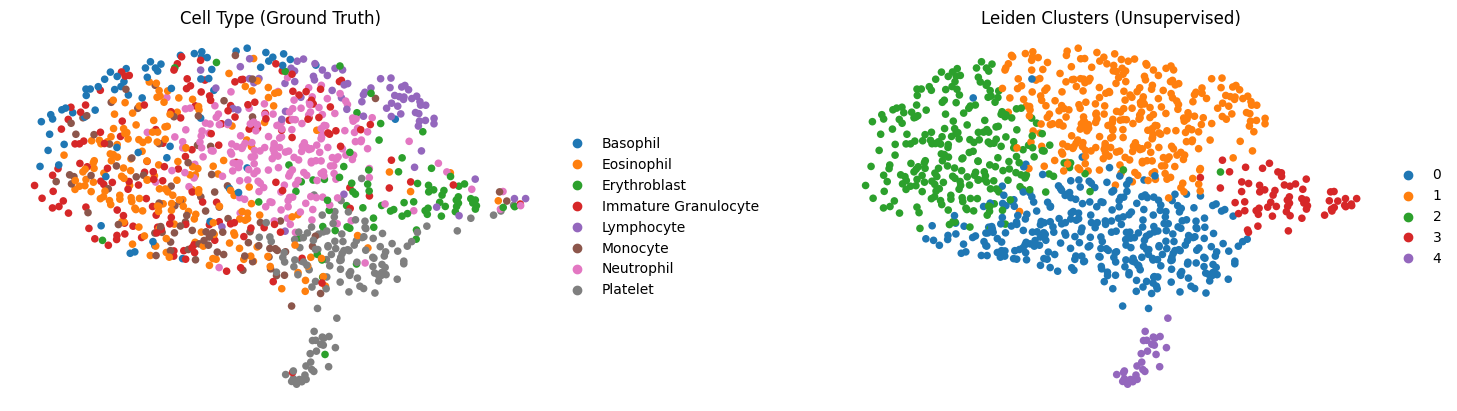

------------------------------
Total cells processed: 1000
Leiden clusters discovered: 5


In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Konfiguration für die Klassennamen
class_names = [
    'Basophil', 'Eosinophil', 'Erythroblast', 'Immature Granulocyte',
    'Lymphocyte', 'Monocyte', 'Neutrophil', 'Platelet'
]

# Vorbereitung der Datenpaare (Name, Embeddings, Labels, Titel)
analysis_configs = [
    {
        "id": "global",
        "emb": final_embeddings_global,
        "lbl": labels_global,
        "title": "Global Normalization BloodMNIST with Protein ID"
    },
    {
        "id": "local",
        "emb": final_embeddings_sample,
        "lbl": labels_sample,
        "title": "Local Normalization BloodMNIST with Protein ID"
    }
]

# Dictionary zum Speichern der Ergebnisse
adatas = {}

for config in analysis_configs:
    print(f"--- Processing: {config['title']} ---")
    
    # 1. AnnData Objekt erstellen
    adata = sc.AnnData(X=config['emb'])
    
    # 2. Labels hinzufügen
    adata.obs['cell_type'] = [class_names[int(l)] for l in config['lbl']]
    
    # 3. Scanpy Pipeline: Nachbarn, UMAP und Leiden Clustering
    sc.pp.neighbors(adata, n_neighbors=15, use_rep='X')
    sc.tl.umap(adata)
    sc.tl.leiden(adata, resolution=0.5, key_added='leiden_clusters')
    
    # Speichern für späteres Plotten
    adatas[config['id']] = adata

# --- PLOTTING ---

# Wir erstellen zwei separate Plots für den direkten Vergleich
for key in ['global', 'local']:
    current_title = next(item['title'] for item in analysis_configs if item['id'] == key)
    
    sc.pl.umap(
        adatas[key], 
        color=['cell_type', 'leiden_clusters'], 
        wspace=0.4, 
        frameon=False, 
        title=[f"{current_title} (Ground Truth)", f"{current_title} (Leiden)"]
    )

# Output Summary
print("-" * 30)
for key, adata in adatas.items():
    print(f"Result {key}: {adata.n_obs} cells, {adata.obs['leiden_clusters'].nunique()} clusters found.")

In [ ]:
-> Plotting the mean aggregation of all the tokens 
-> tokens for Individual patches 
-> plot all images 

-> try different dataset 
-> Merge multople datasets into same uMAp 



Goals: Understand Why are embd distorting the patterns of the Model? 
-> Either embd are shit or projection makes tehm shit 

-> Correlation between rgb channel before and after projection 
-> Compare the embd before and after proojection -> Covarinaz, Heatmap of simple multiplicarions, cosign distnace, pearson  -> how to compare  vectors
-> Visualize images before and after fusion 




